Notebook 7: Landslide Hazard Zonation using AHP
Objective

This notebook generates a Landslide Susceptibility Map (LSM) for Idukki District, Kerala, using the Analytical Hierarchy Process (AHP) and a Weighted Overlay Analysis within a GIS environment. Multiple environmental conditioning factors are integrated to identify areas with varying levels of landslide susceptibility.

Conditioning Factors

The susceptibility model is developed using the following six conditioning factors:

Slope
Aspect
Drainage Density
Rainfall
Normalized Difference Vegetation Index (NDVI)
Land Use/Land Cover (LULC)
Methodology

The workflow consists of the following steps:

Load the preprocessed conditioning factor rasters.
Verify raster alignment, projection, and resolution.
Reclassify each conditioning factor into standardized susceptibility classes.
Assign AHP-derived weights to each factor.
Compute the Landslide Susceptibility Index (LSI) using weighted overlay analysis.
Classify the LSI into five susceptibility categories:
Very Low
Low
Moderate
High
Very High
Export the final susceptibility raster and generate the final susceptibility map.                                                        Note:
Lithology was initially considered as one of the conditioning factors. However, the publicly available geological dataset covered only a single geological sheet (58C13) and did not provide complete spatial coverage of the study area. To maintain methodological consistency and avoid introducing spatial bias, lithology was excluded from the final susceptibility model.

## 1. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.plot import show

from matplotlib.colors import ListedColormap

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Define Project Directories

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/Landslide-Hazard-Zonation"

OUTPUT_RASTERS = os.path.join(PROJECT_DIR, "outputs", "rasters")
OUTPUT_FIGURES = os.path.join(PROJECT_DIR, "outputs", "figures")



## 3. Load Digital Elevation Model (DEM)

In [4]:
DEM_PATH = os.path.join(
    OUTPUT_RASTERS,
    "clipped_dem.tif"
)

with rasterio.open(DEM_PATH) as src:

    dem = src.read(1)

    profile = src.profile

    transform = src.transform

    crs = src.crs

    height = src.height

    width = src.width

print(profile)

{'driver': 'GTiff', 'dtype': 'int16', 'nodata': -32767.0, 'width': 1489, 'height': 2619, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0002777777777777778, 0.0, 76.99986111111112,
       0.0, -0.0002777777777777778, 10.000138888888888), 'blockxsize': 1489, 'blockysize': 2, 'tiled': False, 'interleave': 'band'}


## 4. Load Conditioning Factor Rasters

In [5]:
rasters = {

    "Slope": "slope.tif",

    "Aspect": "aspect.tif",

    "DrainageDensity": "drainage_density.tif",

    "Rainfall": "rainfall.tif",

    "NDVI": "NDVI_2024_03_31.tif",

    "LULC": "LULC_2021.tif"
}

layers = {}

for name, file in rasters.items():

    path = os.path.join(
        OUTPUT_RASTERS,
        file
    )

    with rasterio.open(path) as src:

        layers[name] = src.read(1)


In [6]:
for name, file in rasters.items():

    path = os.path.join(
        OUTPUT_RASTERS,
        file
    )

    with rasterio.open(path) as src:

        print("-"*60)

        print(name)

        print("Shape :", src.shape)

        print("CRS :", src.crs)

        print("Resolution :", src.res)

------------------------------------------------------------
Slope
Shape : (3902, 2823)
CRS : EPSG:4326
Resolution : (0.0002777777777777778, 0.0002777777777777778)
------------------------------------------------------------
Aspect
Shape : (3902, 2823)
CRS : EPSG:4326
Resolution : (0.0002777777777777778, 0.0002777777777777778)
------------------------------------------------------------
DrainageDensity
Shape : (3902, 2823)
CRS : EPSG:4326
Resolution : (0.0002777777777777778, 0.0002777777777777778)
------------------------------------------------------------
Rainfall
Shape : (121, 87)
CRS : EPSG:32643
Resolution : (1000.0, 1000.0)
------------------------------------------------------------
NDVI
Shape : (11986, 8629)
CRS : EPSG:32643
Resolution : (10.0, 10.0)
------------------------------------------------------------
LULC
Shape : (11986, 8629)
CRS : EPSG:32643
Resolution : (10.0, 10.0)


In [ ]:
from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling
)

In [ ]:
ALIGNED_DIR = os.path.join(PROJECT_DIR, "outputs", "aligned_rasters")

os.makedirs(ALIGNED_DIR, exist_ok=True)

In [7]:
from rasterio.warp import reproject, Resampling
import numpy as np

def align_to_dem(input_path, output_path, resampling_method):

    with rasterio.open(input_path) as src:

        # Copy DEM profile
        profile = dem_profile.copy()

        # Create destination array
        destination = np.empty(
            (dem_height, dem_width),
            dtype=src.dtypes[0]
        )

        reproject(
            source=rasterio.band(src, 1),
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dem_transform,
            dst_crs=dem_crs,
            resampling=resampling_method
        )

        # Update profile for the source datatype
        profile.update(
            driver="GTiff",
            dtype=src.dtypes[0],
            count=1,
            compress="lzw"
        )

        # Remove incompatible settings inherited from DEM
        profile.pop("blockxsize", None)
        profile.pop("blockysize", None)
        profile.pop("tiled", None)

        # Set appropriate nodata based on datatype
        if np.issubdtype(np.dtype(src.dtypes[0]), np.integer):
            profile["nodata"] = 0
        else:
            profile["nodata"] = np.nan

        with rasterio.open(output_path, "w", **profile) as dst:
            dst.write(destination, 1)

In [8]:
import rasterio

DEM_PATH = os.path.join(OUTPUT_RASTERS, "idukki_dem.tif")

with rasterio.open(DEM_PATH) as dem_src:

    dem_profile = dem_src.profile

    dem_transform = dem_src.transform

    dem_crs = dem_src.crs

    dem_height = dem_src.height

    dem_width = dem_src.width

print("DEM loaded successfully")
print("Shape:", dem_height, dem_width)
print("CRS:", dem_crs)

DEM loaded successfully
Shape: 3902 2823
CRS: EPSG:4326


## 5. Align Raster Layers

In [11]:
ALIGNED_DIR = os.path.join(PROJECT_DIR, "outputs", "aligned_rasters")
os.makedirs(ALIGNED_DIR, exist_ok=True)

In [12]:
align_to_dem(
    os.path.join(OUTPUT_RASTERS, "rainfall.tif"),
    os.path.join(ALIGNED_DIR, "Rainfall.tif"),
    Resampling.bilinear
)

In [13]:
align_to_dem(
    os.path.join(OUTPUT_RASTERS, "LULC_2021.tif"),
    os.path.join(ALIGNED_DIR, "LULC.tif"),
    Resampling.nearest
)

In [14]:
align_to_dem(
    os.path.join(OUTPUT_RASTERS, "NDVI_2024_03_31.tif"),
    os.path.join(ALIGNED_DIR, "NDVI.tif"),
    Resampling.bilinear
)

In [15]:
aligned_files = ["NDVI.tif", "Rainfall.tif", "LULC.tif"]

for file in aligned_files:
    path = os.path.join(ALIGNED_DIR, file)

    with rasterio.open(path) as src:
        print(f"\n{file}")
        print("Shape:", src.shape)
        print("CRS:", src.crs)
        print("Resolution:", src.res)


NDVI.tif
Shape: (3902, 2823)
CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)

Rainfall.tif
Shape: (3902, 2823)
CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)

LULC.tif
Shape: (3902, 2823)
CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)


In [16]:
# Load all aligned rasters

layers = {}

# Already aligned
with rasterio.open(os.path.join(OUTPUT_RASTERS, "slope.tif")) as src:
    layers["Slope"] = src.read(1)

with rasterio.open(os.path.join(OUTPUT_RASTERS, "aspect.tif")) as src:
    layers["Aspect"] = src.read(1)

with rasterio.open(os.path.join(OUTPUT_RASTERS, "drainage_density.tif")) as src:
    layers["DrainageDensity"] = src.read(1)

# Newly aligned
with rasterio.open(os.path.join(ALIGNED_DIR, "NDVI.tif")) as src:
    layers["NDVI"] = src.read(1)

with rasterio.open(os.path.join(ALIGNED_DIR, "Rainfall.tif")) as src:
    layers["Rainfall"] = src.read(1)

with rasterio.open(os.path.join(ALIGNED_DIR, "LULC.tif")) as src:
    layers["LULC"] = src.read(1)

print("Loaded aligned layers:")
print(list(layers.keys()))

Loaded aligned layers:
['Slope', 'Aspect', 'DrainageDensity', 'NDVI', 'Rainfall', 'LULC']


In [17]:
import numpy as np

for name, arr in layers.items():

    valid = arr[np.isfinite(arr)]

    print("="*50)
    print(name)

    print("Minimum :", np.min(valid))
    print("Maximum :", np.max(valid))

    print("Mean :", np.mean(valid))

    print("Unique values (first 20):")
    print(np.unique(valid)[:20])

    print()

Slope
Minimum : 0.0
Maximum : 89.998505
Mean : 33.453396
Unique values (first 20):
[ 0.       26.565052 35.26439  45.       48.189686 54.73561  56.309933
 57.688465 60.98286  63.434948 64.12331  64.7606   65.90516  68.19859
 68.58328  69.62547  70.52878  71.06818  71.56505  71.79924 ]

Aspect
Minimum : 0.0
Maximum : 359.99838
Mean : 125.668495
Unique values (first 20):
[0.         0.00162652 0.00162777 0.00162795 0.00162832 0.0016292
 0.00162934 0.00163013 0.00163018 0.00163171 0.00163292 0.00163301
 0.00164218 0.0016453  0.00164577 0.00164676 0.00165346 0.00165561
 0.00166108 0.001662  ]

DrainageDensity
Minimum : 0.0
Maximum : 0.44172138
Mean : 0.032984085
Unique values (first 20):
[0.0000000e+00 9.8029603e-05 1.9605921e-04 2.9408882e-04 3.9211841e-04
 4.9014803e-04 5.8817765e-04 6.8620720e-04 6.8620726e-04 7.8423682e-04
 7.8423688e-04 8.8226644e-04 8.8226650e-04 9.8029606e-04 1.0783257e-03
 1.1763552e-03 1.1763553e-03 1.2743848e-03 1.2743849e-03 1.3724144e-03]

NDVI
Minimum : -1.0
M

## 6. Reclassify Conditioning Factors

In [18]:
def reclassify_ranges(array, rules, nodata_value=0):
    """
    Reclassify continuous raster based on value ranges.

    Parameters
    ----------
    array : numpy array
    rules : list of tuples
        (min_value, max_value, output_class)
    nodata_value : value assigned where no rule matches
    """

    output = np.full(array.shape, nodata_value, dtype=np.uint8)

    for low, high, value in rules:
        mask = (array >= low) & (array < high)
        output[mask] = value

    return output

In [19]:
slope_rules = [

    (0,5,1),

    (5,15,2),

    (15,25,3),

    (25,35,4),

    (35,90,5)

]

slope_rc = reclassify_ranges(
    layers["Slope"],
    slope_rules
)

In [20]:
aspect = layers["Aspect"]

aspect_rc = np.ones_like(aspect, dtype=np.uint8)

aspect_rc[(aspect >= 45) & (aspect < 90)] = 2
aspect_rc[(aspect >= 90) & (aspect < 135)] = 3
aspect_rc[(aspect >= 135) & (aspect < 225)] = 5
aspect_rc[(aspect >= 225) & (aspect < 315)] = 3
aspect_rc[(aspect >= 315)] = 2

In [21]:
valid = layers["DrainageDensity"]

q20, q40, q60, q80 = np.percentile(
    valid[valid > 0],
    [20,40,60,80]
)

drainage_rc = np.ones_like(valid, dtype=np.uint8)

drainage_rc[valid > q20] = 2
drainage_rc[valid > q40] = 3
drainage_rc[valid > q60] = 4
drainage_rc[valid > q80] = 5

In [22]:
valid = layers["Rainfall"]

q20, q40, q60, q80 = np.percentile(
    valid[valid > 0],
    [20,40,60,80]
)

rainfall_rc = np.ones_like(valid, dtype=np.uint8)

rainfall_rc[valid > q20] = 2
rainfall_rc[valid > q40] = 3
rainfall_rc[valid > q60] = 4
rainfall_rc[valid > q80] = 5

In [23]:
ndvi = layers["NDVI"]

ndvi_rc = np.zeros_like(ndvi, dtype=np.uint8)

ndvi_rc[ndvi > 0.6] = 1
ndvi_rc[(ndvi > 0.4) & (ndvi <= 0.6)] = 2
ndvi_rc[(ndvi > 0.2) & (ndvi <= 0.4)] = 3
ndvi_rc[(ndvi > 0.0) & (ndvi <= 0.2)] = 4
ndvi_rc[ndvi <= 0.0] = 5

In [24]:
lulc = layers["LULC"]

lulc_rc = np.zeros_like(lulc, dtype=np.uint8)

# Tree Cover
lulc_rc[lulc == 10] = 1

# Grassland
lulc_rc[lulc == 30] = 3

# Cropland
lulc_rc[lulc == 40] = 4

# Built-up
lulc_rc[lulc == 50] = 5

# Bare land
lulc_rc[lulc == 60] = 5

# Water
lulc_rc[lulc == 80] = 1

# Wetland
lulc_rc[lulc == 90] = 2

In [25]:
for name, arr in {

    "Slope": slope_rc,

    "Aspect": aspect_rc,

    "Drainage": drainage_rc,

    "Rainfall": rainfall_rc,

    "NDVI": ndvi_rc,

    "LULC": lulc_rc

}.items():

    print(name)

    print(np.unique(arr))

    print()

Slope
[1 4 5]

Aspect
[1 2 3 5]

Drainage
[1 2 3 4 5]

Rainfall
[1 2 3 4 5]

NDVI
[0 1 2 3 4 5]

LULC
[0 1 2 3 4 5]



In [26]:
import rasterio
import os

for raster in ["NDVI.tif", "Rainfall.tif", "LULC.tif"]:

    path = os.path.join(ALIGNED_DIR, raster)

    with rasterio.open(path) as src:
        print("="*50)
        print(raster)
        print("Shape:", src.shape)
        print("CRS:", src.crs)
        print("Resolution:", src.res)

NDVI.tif
Shape: (3902, 2823)
CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Rainfall.tif
Shape: (3902, 2823)
CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)
LULC.tif
Shape: (3902, 2823)
CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)


In [27]:
align_to_dem(
    os.path.join(OUTPUT_RASTERS, "NDVI_2024_03_31.tif"),
    os.path.join(ALIGNED_DIR, "NDVI.tif"),
    Resampling.bilinear
)

In [28]:
import rasterio
import os

with rasterio.open(os.path.join(ALIGNED_DIR, "NDVI.tif")) as src:
    print("Shape:", src.shape)
    print("CRS:", src.crs)
    print("Resolution:", src.res)

Shape: (3902, 2823)
CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)


In [29]:
layers = {}

files = {
    "Slope": os.path.join(OUTPUT_RASTERS, "slope.tif"),
    "Aspect": os.path.join(OUTPUT_RASTERS, "aspect.tif"),
    "Drainage": os.path.join(OUTPUT_RASTERS, "drainage_density.tif"),
    "Rainfall": os.path.join(ALIGNED_DIR, "Rainfall.tif"),
    "NDVI": os.path.join(ALIGNED_DIR, "NDVI.tif"),
    "LULC": os.path.join(ALIGNED_DIR, "LULC.tif")
}

for name, path in files.items():
    with rasterio.open(path) as src:
        layers[name] = src.read(1)

print("Loaded layers:")
print(list(layers.keys()))

Loaded layers:
['Slope', 'Aspect', 'Drainage', 'Rainfall', 'NDVI', 'LULC']


In [30]:
for name, arr in layers.items():
    print(name, arr.shape)

Slope (3902, 2823)
Aspect (3902, 2823)
Drainage (3902, 2823)
Rainfall (3902, 2823)
NDVI (3902, 2823)
LULC (3902, 2823)


In [31]:
import numpy as np

slope = layers["Slope"]

slope_rc = np.select(
    [
        slope < 15,
        (slope >= 15) & (slope < 25),
        (slope >= 25) & (slope < 35),
        (slope >= 35) & (slope < 45),
        slope >= 45
    ],
    [1, 2, 3, 4, 5],
    default=0
)

In [32]:
aspect = layers["Aspect"]

aspect_rc = np.select(
    [
        ((aspect >= 0) & (aspect < 45)) | ((aspect >= 315) & (aspect <= 360)),
        (aspect >= 45) & (aspect < 135),
        (aspect >= 135) & (aspect < 225),
        (aspect >= 225) & (aspect < 315)
    ],
    [
        3,   # North
        5,   # East
        2,   # South
        4    # West
    ],
    default=1
)

print(np.unique(aspect_rc))

[2 3 4 5]


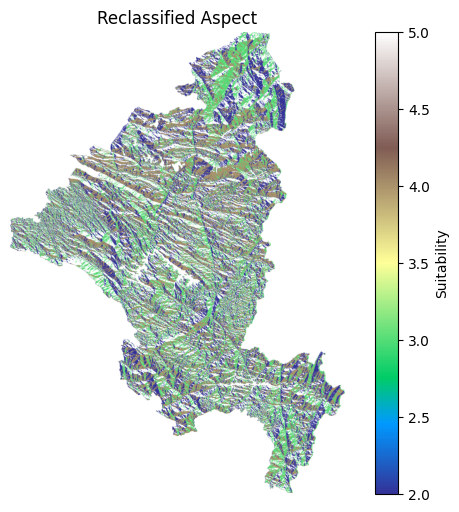

In [33]:
plt.figure(figsize=(8,6))
plt.imshow(aspect_rc, cmap="terrain")
plt.title("Reclassified Aspect")
plt.colorbar(label="Suitability")
plt.axis("off")
plt.show()

In [34]:
for c in range(1, 6):
    print(f"Class {c}: {(aspect_rc == c).sum()}")

Class 1: 0
Class 2: 1087680
Class 3: 965617
Class 4: 1284817
Class 5: 7677232


In [35]:
drainage = layers["Drainage"]

print("Minimum:", drainage.min())
print("Maximum:", drainage.max())

Minimum: 0.0
Maximum: 0.44172138


In [36]:
drainage_rc = np.select(
    [
        drainage < 0.02,
        (drainage >= 0.02) & (drainage < 0.05),
        (drainage >= 0.05) & (drainage < 0.10),
        (drainage >= 0.10) & (drainage < 0.20),
        drainage >= 0.20
    ],
    [1, 2, 3, 4, 5],
    default=0
)

print("Unique classes:", np.unique(drainage_rc))

Unique classes: [1 2 3 4 5]


In [37]:
for c in range(1, 6):
    print(f"Class {c}: {(drainage_rc == c).sum()}")

Class 1: 6700278
Class 2: 3057826
Class 3: 510274
Class 4: 302029
Class 5: 444939


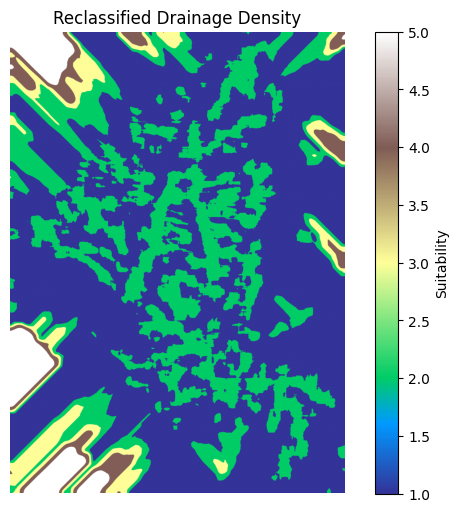

In [38]:
plt.figure(figsize=(8,6))
plt.imshow(drainage_rc, cmap="terrain")
plt.title("Reclassified Drainage Density")
plt.colorbar(label="Suitability")
plt.axis("off")
plt.show()

In [39]:
print(np.unique(drainage_rc))

for i in range(1, 6):
    print(f"Class {i}: {(drainage_rc == i).sum()}")

[1 2 3 4 5]
Class 1: 6700278
Class 2: 3057826
Class 3: 510274
Class 4: 302029
Class 5: 444939


In [40]:
import numpy as np

rainfall = layers["Rainfall"]

print("Shape:", rainfall.shape)
print("NaN count:", np.isnan(rainfall).sum())
print("Total pixels:", rainfall.size)

Shape: (3902, 2823)
NaN count: 6354071
Total pixels: 11015346


In [41]:
valid = rainfall[~np.isnan(rainfall)]

print("Valid pixels:", len(valid))

if len(valid) > 0:
    print("Minimum:", valid.min())
    print("Maximum:", valid.max())

Valid pixels: 4661275
Minimum: 0.0
Maximum: 4110.715


In [42]:
np.nanmin(rainfall)
np.nanmax(rainfall)

np.float32(4110.715)

In [43]:
rainfall.min()
rainfall.max()

np.float32(nan)

In [44]:
import numpy as np

rainfall = layers["Rainfall"]

print("Shape:", rainfall.shape)
print("Total pixels:", rainfall.size)
print("NaN pixels:", np.isnan(rainfall).sum())

valid = rainfall[~np.isnan(rainfall)]

print("Valid pixels:", len(valid))

if len(valid) > 0:
    print("Min:", valid.min())
    print("Max:", valid.max())
else:
    print("No valid pixels found.")

Shape: (3902, 2823)
Total pixels: 11015346
NaN pixels: 6354071
Valid pixels: 4661275
Min: 0.0
Max: 4110.715


In [45]:
import rasterio

with rasterio.open(os.path.join(ALIGNED_DIR, "Rainfall.tif")) as src:
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Nodata:", src.nodata)

CRS: EPSG:4326
Bounds: BoundingBox(left=76.62930555555556, bottom=9.272638888888887, right=77.41347222222223, top=10.356527777777776)
Nodata: nan


In [46]:
import numpy as np

with rasterio.open(os.path.join(ALIGNED_DIR, "Rainfall.tif")) as src:
    rain = src.read(1)

print("Total pixels:", rain.size)
print("NaN pixels:", np.isnan(rain).sum())
print("Valid pixels:", np.count_nonzero(~np.isnan(rain)))

if np.count_nonzero(~np.isnan(rain)) > 0:
    print("Minimum:", np.nanmin(rain))
    print("Maximum:", np.nanmax(rain))

Total pixels: 11015346
NaN pixels: 6354071
Valid pixels: 4661275
Minimum: 0.0
Maximum: 4110.715


In [47]:
import numpy as np

rainfall = layers["Rainfall"]

rainfall_rc = np.full(rainfall.shape, 0, dtype=np.uint8)

mask = ~np.isnan(rainfall)

rainfall_rc[mask] = np.select(
    [
        rainfall[mask] < 1800,
        (rainfall[mask] >= 1800) & (rainfall[mask] < 2200),
        (rainfall[mask] >= 2200) & (rainfall[mask] < 2600),
        (rainfall[mask] >= 2600) & (rainfall[mask] < 3000),
        rainfall[mask] >= 3000
    ],
    [1, 2, 3, 4, 5]
)

print(np.unique(rainfall_rc))

[0 1 2 3 4 5]


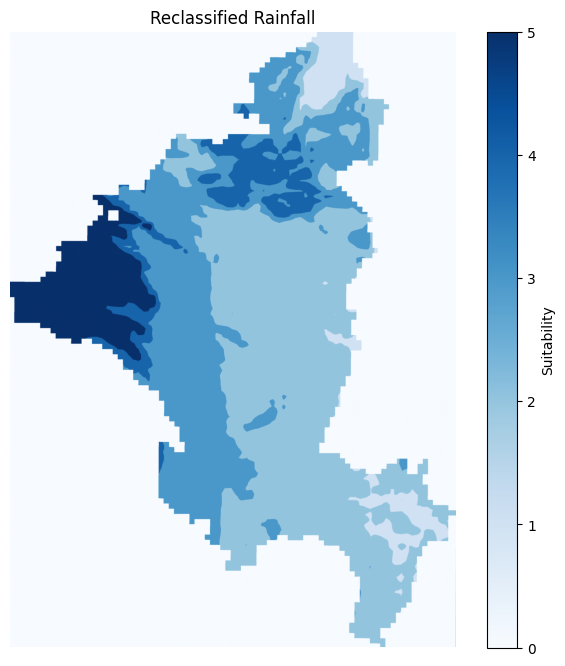

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(rainfall_rc, cmap="Blues")
plt.title("Reclassified Rainfall")
plt.colorbar(label="Suitability")
plt.axis("off")
plt.show()

In [49]:
for c in range(1,6):
    print(f"Class {c}: {(rainfall_rc==c).sum()}")

Class 1: 261858
Class 2: 2198393
Class 3: 1396561
Class 4: 344038
Class 5: 460425


In [50]:
import numpy as np

ndvi = layers["NDVI"]

ndvi_rc = np.full(ndvi.shape, 0, dtype=np.uint8)

mask = ~np.isnan(ndvi)

q20, q40, q60, q80 = np.nanpercentile(ndvi[mask], [20, 40, 60, 80])

print("Percentiles:")
print(q20, q40, q60, q80)

ndvi_rc[mask] = np.select(
    [
        ndvi[mask] <= q20,
        (ndvi[mask] > q20) & (ndvi[mask] <= q40),
        (ndvi[mask] > q40) & (ndvi[mask] <= q60),
        (ndvi[mask] > q60) & (ndvi[mask] <= q80),
        ndvi[mask] > q80
    ],
    [5, 4, 3, 2, 1]
)

print("Unique classes:", np.unique(ndvi_rc))

Percentiles:
0.4170657813549042 0.621303915977478 0.7350009799003601 0.8046334266662598
Unique classes: [0 1 2 3 4 5]


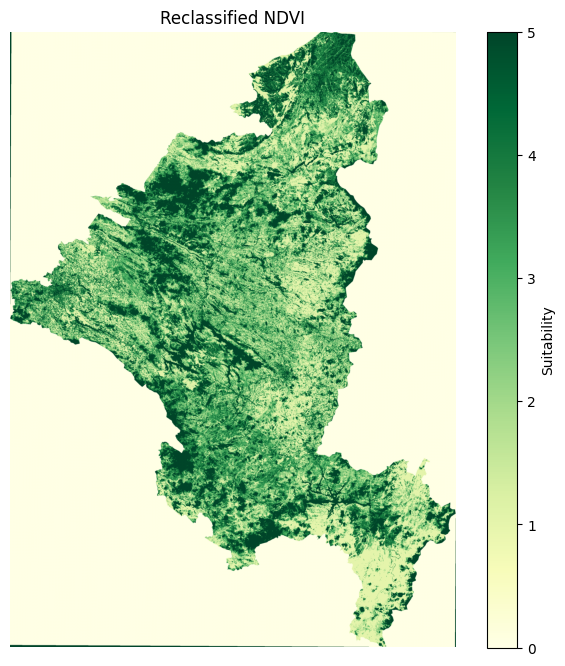

In [51]:
plt.figure(figsize=(8,8))
plt.imshow(ndvi_rc, cmap="YlGn")
plt.title("Reclassified NDVI")
plt.colorbar(label="Suitability")
plt.axis("off")
plt.show()

In [52]:
import numpy as np

lulc = layers["LULC"]

classes, counts = np.unique(lulc, return_counts=True)

for c, n in zip(classes, counts):
    print(f"Class {c}: {n}")

Class 0: 6359098
Class 10: 3915098
Class 20: 34
Class 30: 632189
Class 40: 5331
Class 50: 30555
Class 60: 1052
Class 80: 71981
Class 90: 8


In [53]:
lulc = layers["LULC"]

lulc_rc = np.zeros(lulc.shape, dtype=np.uint8)

lulc_rc[lulc == 10] = 1
lulc_rc[lulc == 20] = 2
lulc_rc[lulc == 30] = 2
lulc_rc[lulc == 40] = 5
lulc_rc[lulc == 50] = 4
lulc_rc[lulc == 60] = 3
lulc_rc[lulc == 80] = 1
lulc_rc[lulc == 90] = 2

print("Unique classes:", np.unique(lulc_rc))

Unique classes: [0 1 2 3 4 5]


In [54]:
for c in range(6):
    print(f"Class {c}: {(lulc_rc == c).sum()}")

Class 0: 6359098
Class 1: 3987079
Class 2: 632231
Class 3: 1052
Class 4: 30555
Class 5: 5331


## 7. Assign AHP Weights

In [55]:
weights = {
    "Slope": 0.30,
    "Rainfall": 0.25,
    "Drainage": 0.15,
    "LULC": 0.12,
    "NDVI": 0.10,
    "Aspect": 0.08
}



## 8. Compute Landslide Susceptibility Index (LSI)

In [56]:
LSI = (
    slope_rc * weights["Slope"] +
    rainfall_rc * weights["Rainfall"] +
    drainage_rc * weights["Drainage"] +
    lulc_rc * weights["LULC"] +
    ndvi_rc * weights["NDVI"] +
    aspect_rc * weights["Aspect"]
)

print("Minimum:", np.nanmin(LSI))
print("Maximum:", np.nanmax(LSI))
print("Mean:", np.nanmean(LSI))

Minimum: 0.85
Maximum: 4.550000000000001
Mean: 1.8624988184665257


## 9. Classify Landslide Susceptibility

In [58]:
import numpy as np

# Ignore any NaN values
valid = LSI[~np.isnan(LSI)]

q20, q40, q60, q80 = np.percentile(valid, [20, 40, 60, 80])

print("Breaks:")
print(q20, q40, q60, q80)

LSI_class = np.select(
    [
        LSI <= q20,
        (LSI > q20) & (LSI <= q40),
        (LSI > q40) & (LSI <= q60),
        (LSI > q60) & (LSI <= q80),
        LSI > q80
    ],
    [1, 2, 3, 4, 5],
    default=0
)

print(np.unique(LSI_class))

Breaks:
0.85 1.0 2.5300000000000002 3.08
[1 2 3 4 5]


In [59]:
for c in range(1, 6):
    print(f"Class {c}: {(LSI_class == c).sum()}")

Class 1: 3967576
Class 2: 1039412
Class 3: 1608174
Class 4: 2236644
Class 5: 2163540


## 10. Results and Visualization

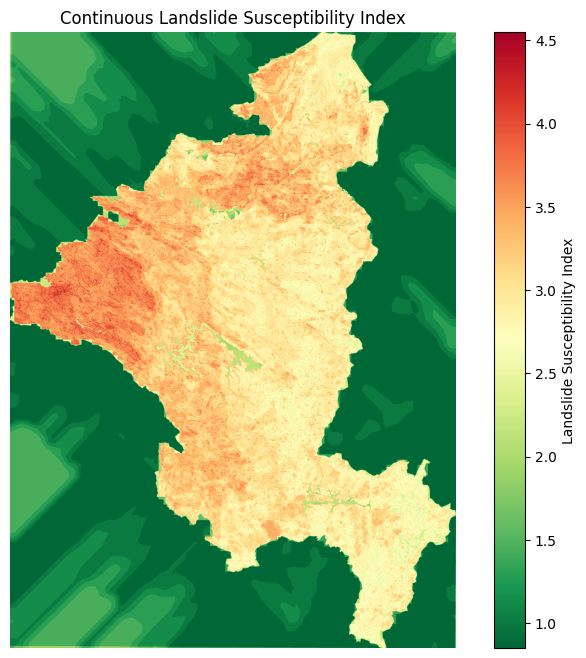

In [57]:
plt.figure(figsize=(10,8))

plt.imshow(LSI, cmap="RdYlGn_r")

plt.colorbar(label="Landslide Susceptibility Index")

plt.title("Continuous Landslide Susceptibility Index")

plt.axis("off")

plt.show()

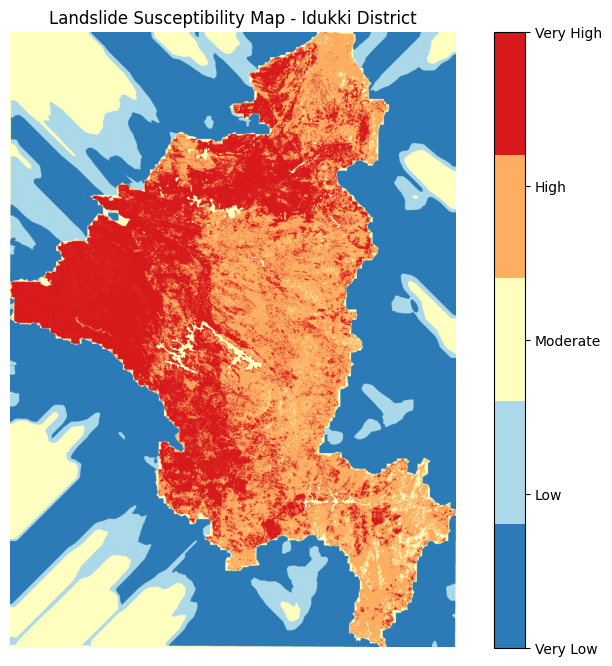

In [60]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

colors = [
    "#2c7bb6",  # Very Low
    "#abd9e9",  # Low
    "#ffffbf",  # Moderate
    "#fdae61",  # High
    "#d7191c"   # Very High
]

cmap = ListedColormap(colors)

plt.figure(figsize=(10, 8))

im = plt.imshow(LSI_class, cmap=cmap)

cbar = plt.colorbar(im, ticks=[1, 2, 3, 4, 5])

cbar.ax.set_yticklabels([
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
])

plt.title("Landslide Susceptibility Map - Idukki District")

plt.axis("off")

plt.show()

In [61]:
import rasterio
import os

output_path = os.path.join(
    OUTPUT_RASTERS,
    "Landslide_Susceptibility_Map.tif"
)

profile = dem_profile.copy()

profile.update(
    dtype=rasterio.uint8,
    count=1,
    compress="lzw",
    nodata=0
)

with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(LSI_class.astype(rasterio.uint8), 1)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/Landslide_Susceptibility_Map.tif


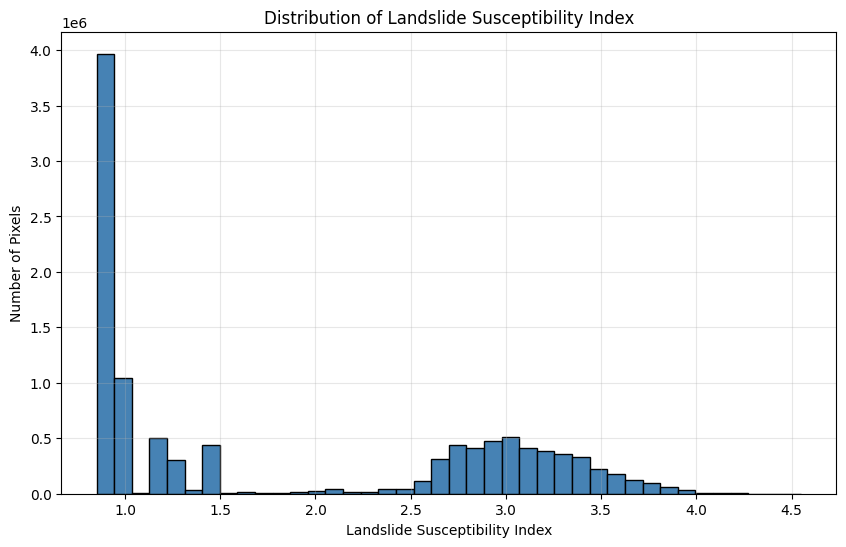

In [62]:
plt.figure(figsize=(10,6))

plt.hist(
    LSI[~np.isnan(LSI)],
    bins=40,
    color="steelblue",
    edgecolor="black"
)

plt.xlabel("Landslide Susceptibility Index")
plt.ylabel("Number of Pixels")
plt.title("Distribution of Landslide Susceptibility Index")

plt.grid(alpha=0.3)

plt.show()

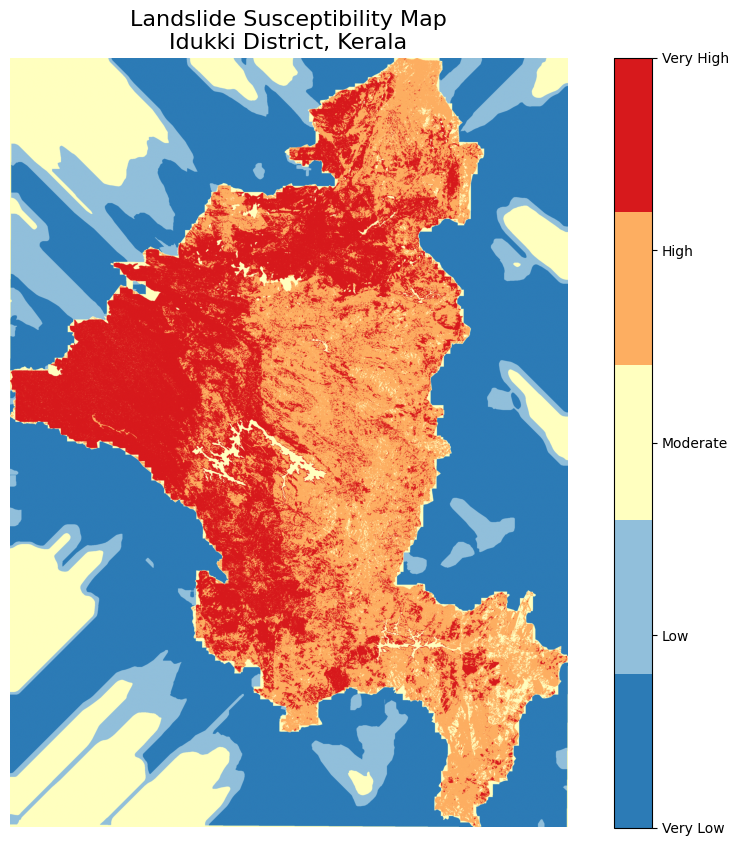

In [63]:
from matplotlib.colors import ListedColormap

colors = [
    "#2c7bb6",   # Very Low
    "#91bfdb",   # Low
    "#ffffbf",   # Moderate
    "#fdae61",   # High
    "#d7191c"    # Very High
]

labels = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

cmap = ListedColormap(colors)

plt.figure(figsize=(12,10))

im = plt.imshow(LSI_class, cmap=cmap)

cbar = plt.colorbar(im)

cbar.set_ticks([1,2,3,4,5])

cbar.set_ticklabels(labels)

plt.title(
    "Landslide Susceptibility Map\nIdukki District, Kerala",
    fontsize=16
)

plt.axis("off")

plt.show()

In [64]:
import pandas as pd

classes, counts = np.unique(
    LSI_class,
    return_counts=True
)

stats = pd.DataFrame({
    "Class": classes,
    "Pixels": counts
})

stats = stats[stats["Class"] != 0]

stats["Percentage"] = (
    stats["Pixels"] /
    stats["Pixels"].sum()
) * 100

stats["Susceptibility"] = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

stats

,Class,Pixels,Percentage,Susceptibility
0,1,3967576,36.018623,Very Low
1,2,1039412,9.436036,Low
2,3,1608174,14.599396,Moderate
3,4,2236644,20.304800,High
4,5,2163540,19.641144,Very High


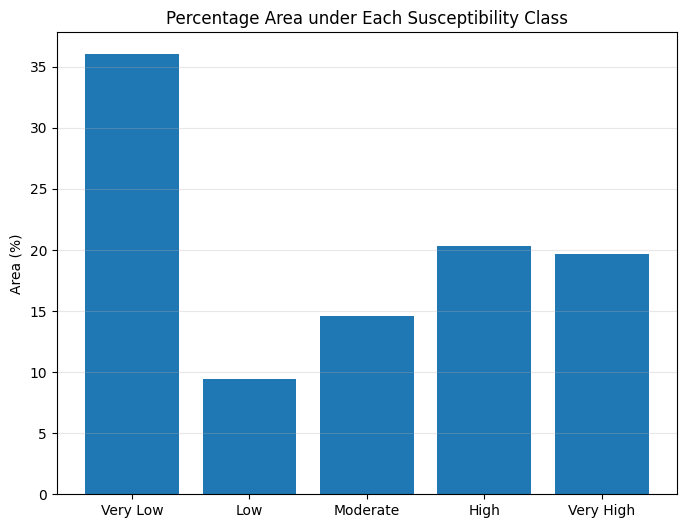

In [65]:
plt.figure(figsize=(8,6))

plt.bar(
    stats["Susceptibility"],
    stats["Percentage"]
)

plt.ylabel("Area (%)")

plt.title(
    "Percentage Area under Each Susceptibility Class"
)

plt.grid(axis="y", alpha=0.3)

plt.show()

## 11. Export Outputs

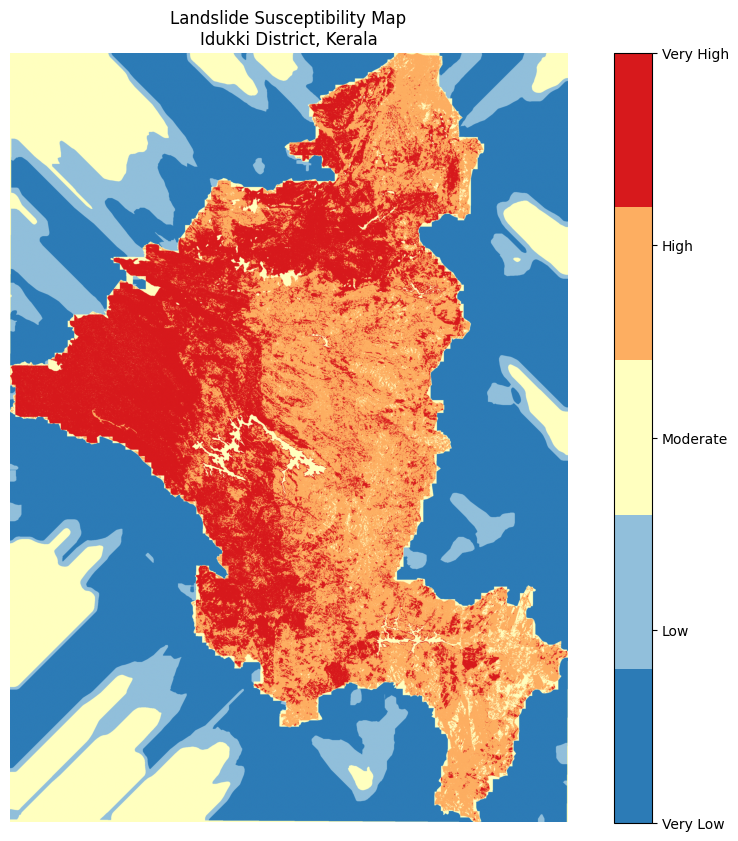

In [66]:
plt.figure(figsize=(12,10))

im = plt.imshow(LSI_class, cmap=cmap)

cbar = plt.colorbar(im)

cbar.set_ticks([1,2,3,4,5])

cbar.set_ticklabels(labels)

plt.title(
    "Landslide Susceptibility Map\nIdukki District, Kerala"
)

plt.axis("off")

plt.savefig(
    os.path.join(
        OUTPUT_RASTERS,
        "Landslide_Susceptibility_Map.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()